In [20]:
"""
HAM10000 Dataset - Exploratory Data Analysis
This notebook explores class distribution, image properties, and data quality.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Paths
PROJECT_ROOT = Path.cwd().parent  # Assuming notebook is in notebooks/
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
METADATA_PATH = DATA_DIR / "metadata.csv"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_DIR}")
print(f"Metadata: {METADATA_PATH}")

Project Root: /Users/nikhilmourya/Desktop/dermavision
Data Directory: /Users/nikhilmourya/Desktop/dermavision/data
Metadata: /Users/nikhilmourya/Desktop/dermavision/data/metadata.csv


In [21]:
# Load metadata
df = pd.read_csv(METADATA_PATH)

print(f" Loaded {len(df)} samples\n")
print(" Dataset Info:")
print(df.info())
print("\n" )
print("First few rows:")
df.head()

 Loaded 10015 samples

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   split         10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB
None


First few rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization,split
0,HAM_0005972,ISIC_0033319,nv,histo,35.0,female,lower extremity,train
1,HAM_0004902,ISIC_0030823,nv,follow_up,40.0,male,trunk,train
2,HAM_0005282,ISIC_0028730,akiec,histo,65.0,male,lower extremity,train
3,HAM_0000475,ISIC_0027299,nv,follow_up,40.0,male,lower extremity,train
4,HAM_0000949,ISIC_0032444,nv,histo,65.0,male,back,train


In [22]:
# Class mapping (abbreviated codes to full names)
CLASS_NAMES = {
    'nv': 'Melanocytic Nevi (Moles)',
    'mel': 'Melanoma',
    'bkl': 'Benign Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses',
    'vasc': 'Vascular Lesions',
    'df': 'Dermatofibroma'
}

# Add readable class names
df['dx_full'] = df['dx'].map(CLASS_NAMES)

# Overall class distribution
class_counts = df['dx'].value_counts()
class_percentages = (class_counts / len(df) * 100).round(2)

print("Class Distribution:\n")
for cls, count in class_counts.items():
    pct = class_percentages[cls]
    full_name = CLASS_NAMES[cls]
    print(f"  {cls:6s} ({full_name:30s}): {count:5d} ({pct:5.2f}%)")

print(f"\nImbalance Ratio: {class_counts.max() / class_counts.min():.1f}:1")
print(f"(Most common class is {class_counts.max() / class_counts.min():.1f}x more frequent than rarest)")

Class Distribution:

  nv     (Melanocytic Nevi (Moles)      ):  6705 (66.95%)
  mel    (Melanoma                      ):  1113 (11.11%)
  bkl    (Benign Keratosis              ):  1099 (10.97%)
  bcc    (Basal Cell Carcinoma          ):   514 ( 5.13%)
  akiec  (Actinic Keratoses             ):   327 ( 3.27%)
  vasc   (Vascular Lesions              ):   142 ( 1.42%)
  df     (Dermatofibroma                ):   115 ( 1.15%)

Imbalance Ratio: 58.3:1
(Most common class is 58.3x more frequent than rarest)


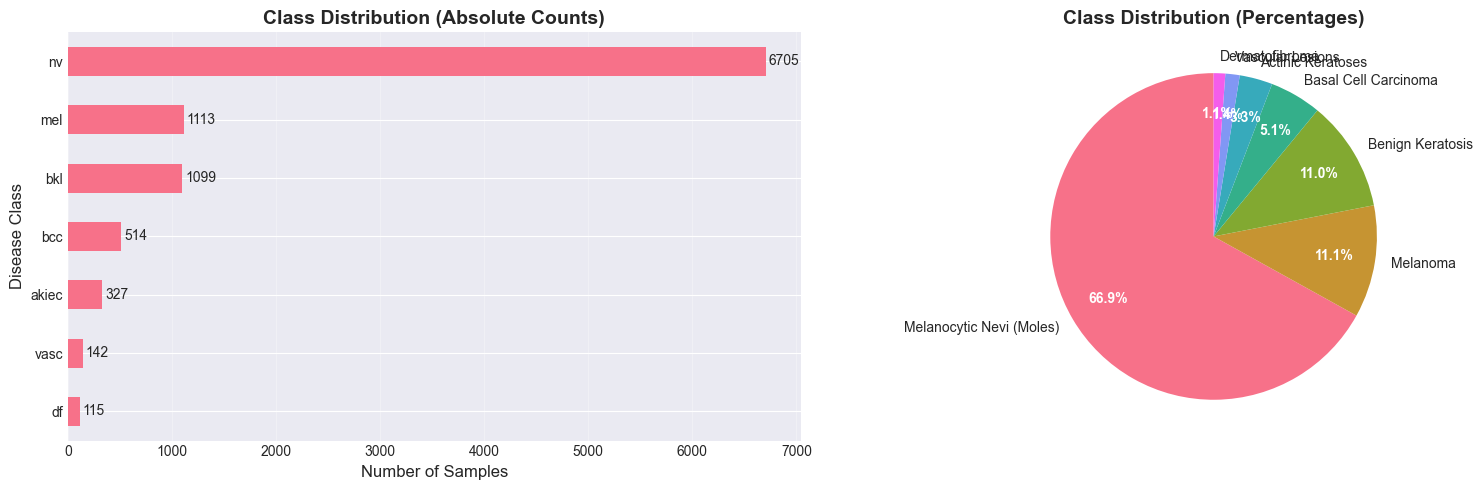


Critical Class (Melanoma):
Count: 1113
Percentage: 11.11%
This is the class where we must prioritize high sensitivity.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Calculate percentages safely
class_percentages = (class_counts / class_counts.sum()) * 100

# Sort once and reuse
sorted_counts = class_counts.sort_values(ascending=True)

# -------------------------
# Plot 1: Bar chart
# -------------------------
ax1 = axes[0]

sorted_counts.plot(
    kind='barh',
    ax=ax1
)

ax1.set_xlabel('Number of Samples', fontsize=12)
ax1.set_ylabel('Disease Class', fontsize=12)
ax1.set_title('Class Distribution (Absolute Counts)', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add labels to bars
for i, count in enumerate(sorted_counts.values):
    ax1.text(count + 30, i, str(count), va='center', fontsize=10)

# -------------------------
# Plot 2: Pie chart
# -------------------------
ax2 = axes[1]

colors = sns.color_palette("husl", len(class_counts))

wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=[CLASS_NAMES[c] for c in class_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75
)

ax2.set_title('Class Distribution (Percentages)', fontsize=14, fontweight='bold')

# Style percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# -------------------------
# Highlight melanoma
# -------------------------
mel_count = class_counts.loc['mel']
mel_pct = class_percentages.loc['mel']

print("\nCritical Class (Melanoma):")
print(f"Count: {mel_count}")
print(f"Percentage: {mel_pct:.2f}%")
print("This is the class where we must prioritize high sensitivity.")

Dataset Splits:

  Train:  8012 (80.00%)
  Test :  1002 (10.00%)
  Val  :  1001 (10.00%)

Class Distribution per Split:

dx     akiec  bcc  bkl  df  mel    nv  vasc
split                                      
test      32   52  110  11  112   671    14
train    262  411  879  92  890  5364   114
val       33   51  110  12  111   670    14


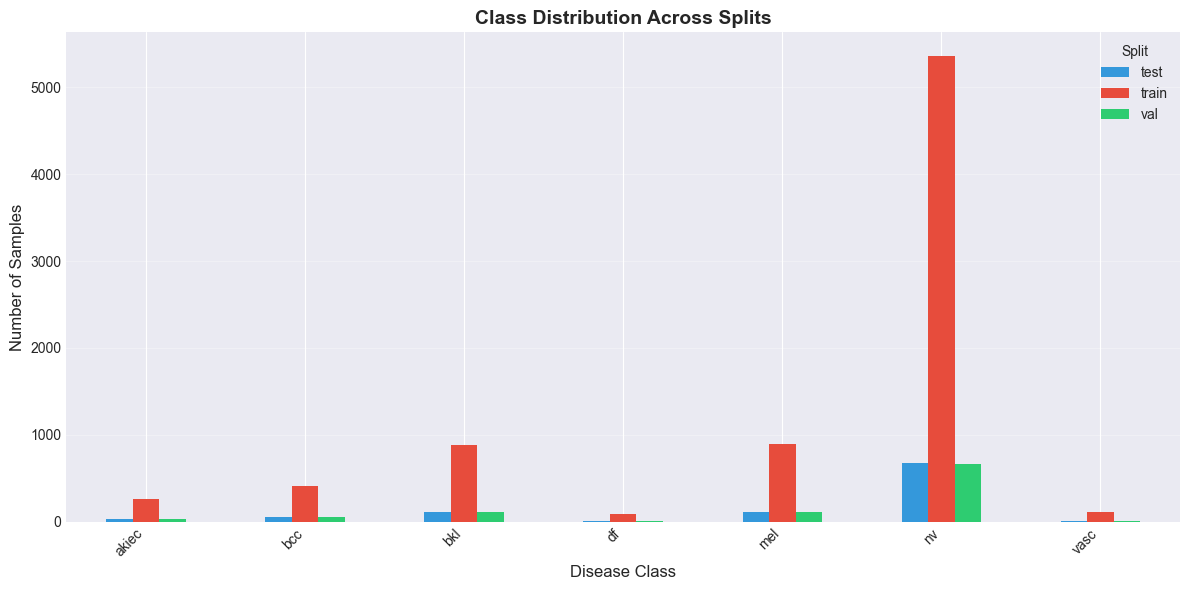

In [24]:
# Check split distribution
split_counts = df['split'].value_counts()

print("Dataset Splits:\n")
for split, count in split_counts.items():
    pct = (count / len(df) * 100)
    print(f"  {split.capitalize():5s}: {count:5d} ({pct:5.2f}%)")

# Check class distribution per split
print("\nClass Distribution per Split:\n")
split_class_dist = df.groupby(['split', 'dx']).size().unstack(fill_value=0)
print(split_class_dist)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
split_class_dist.T.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_xlabel('Disease Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution Across Splits', fontsize=14, fontweight='bold')
ax.legend(title='Split', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

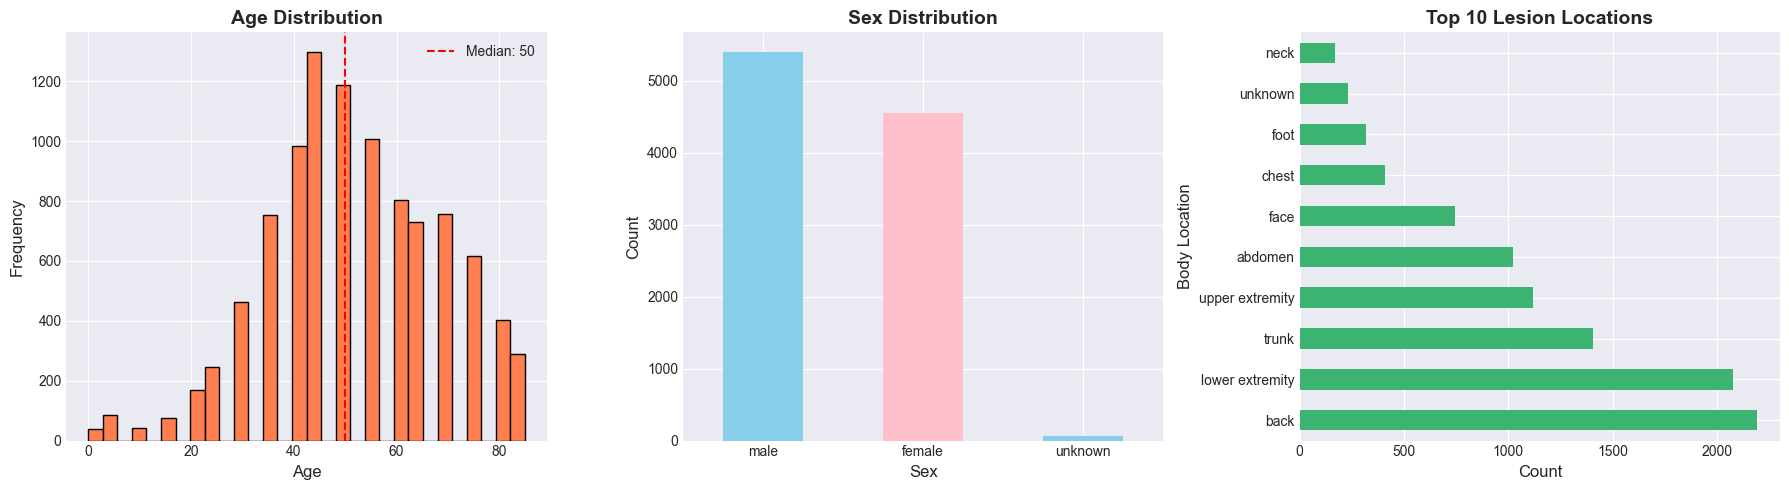


 Age Statistics:
   Mean: 51.9 years
   Median: 50.0 years
   Range: 0 - 85 years


In [25]:
# Age distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Age distribution
ax1 = axes[0]
df['age'].hist(bins=30, ax=ax1, color='coral', edgecolor='black')
ax1.set_xlabel('Age', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax1.axvline(df['age'].median(), color='red', linestyle='--', label=f'Median: {df["age"].median():.0f}')
ax1.legend()

# Plot 2: Sex distribution
ax2 = axes[1]
sex_counts = df['sex'].value_counts()
sex_counts.plot(kind='bar', ax=ax2, color=['skyblue', 'pink'])
ax2.set_xlabel('Sex', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Sex Distribution', fontsize=14, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# Plot 3: Lesion location
ax3 = axes[2]
loc_counts = df['localization'].value_counts().head(10)
loc_counts.plot(kind='barh', ax=ax3, color='mediumseagreen')
ax3.set_xlabel('Count', fontsize=12)
ax3.set_ylabel('Body Location', fontsize=12)
ax3.set_title('Top 10 Lesion Locations', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Age Statistics:")
print(f"   Mean: {df['age'].mean():.1f} years")
print(f"   Median: {df['age'].median():.1f} years")
print(f"   Range: {df['age'].min():.0f} - {df['age'].max():.0f} years")

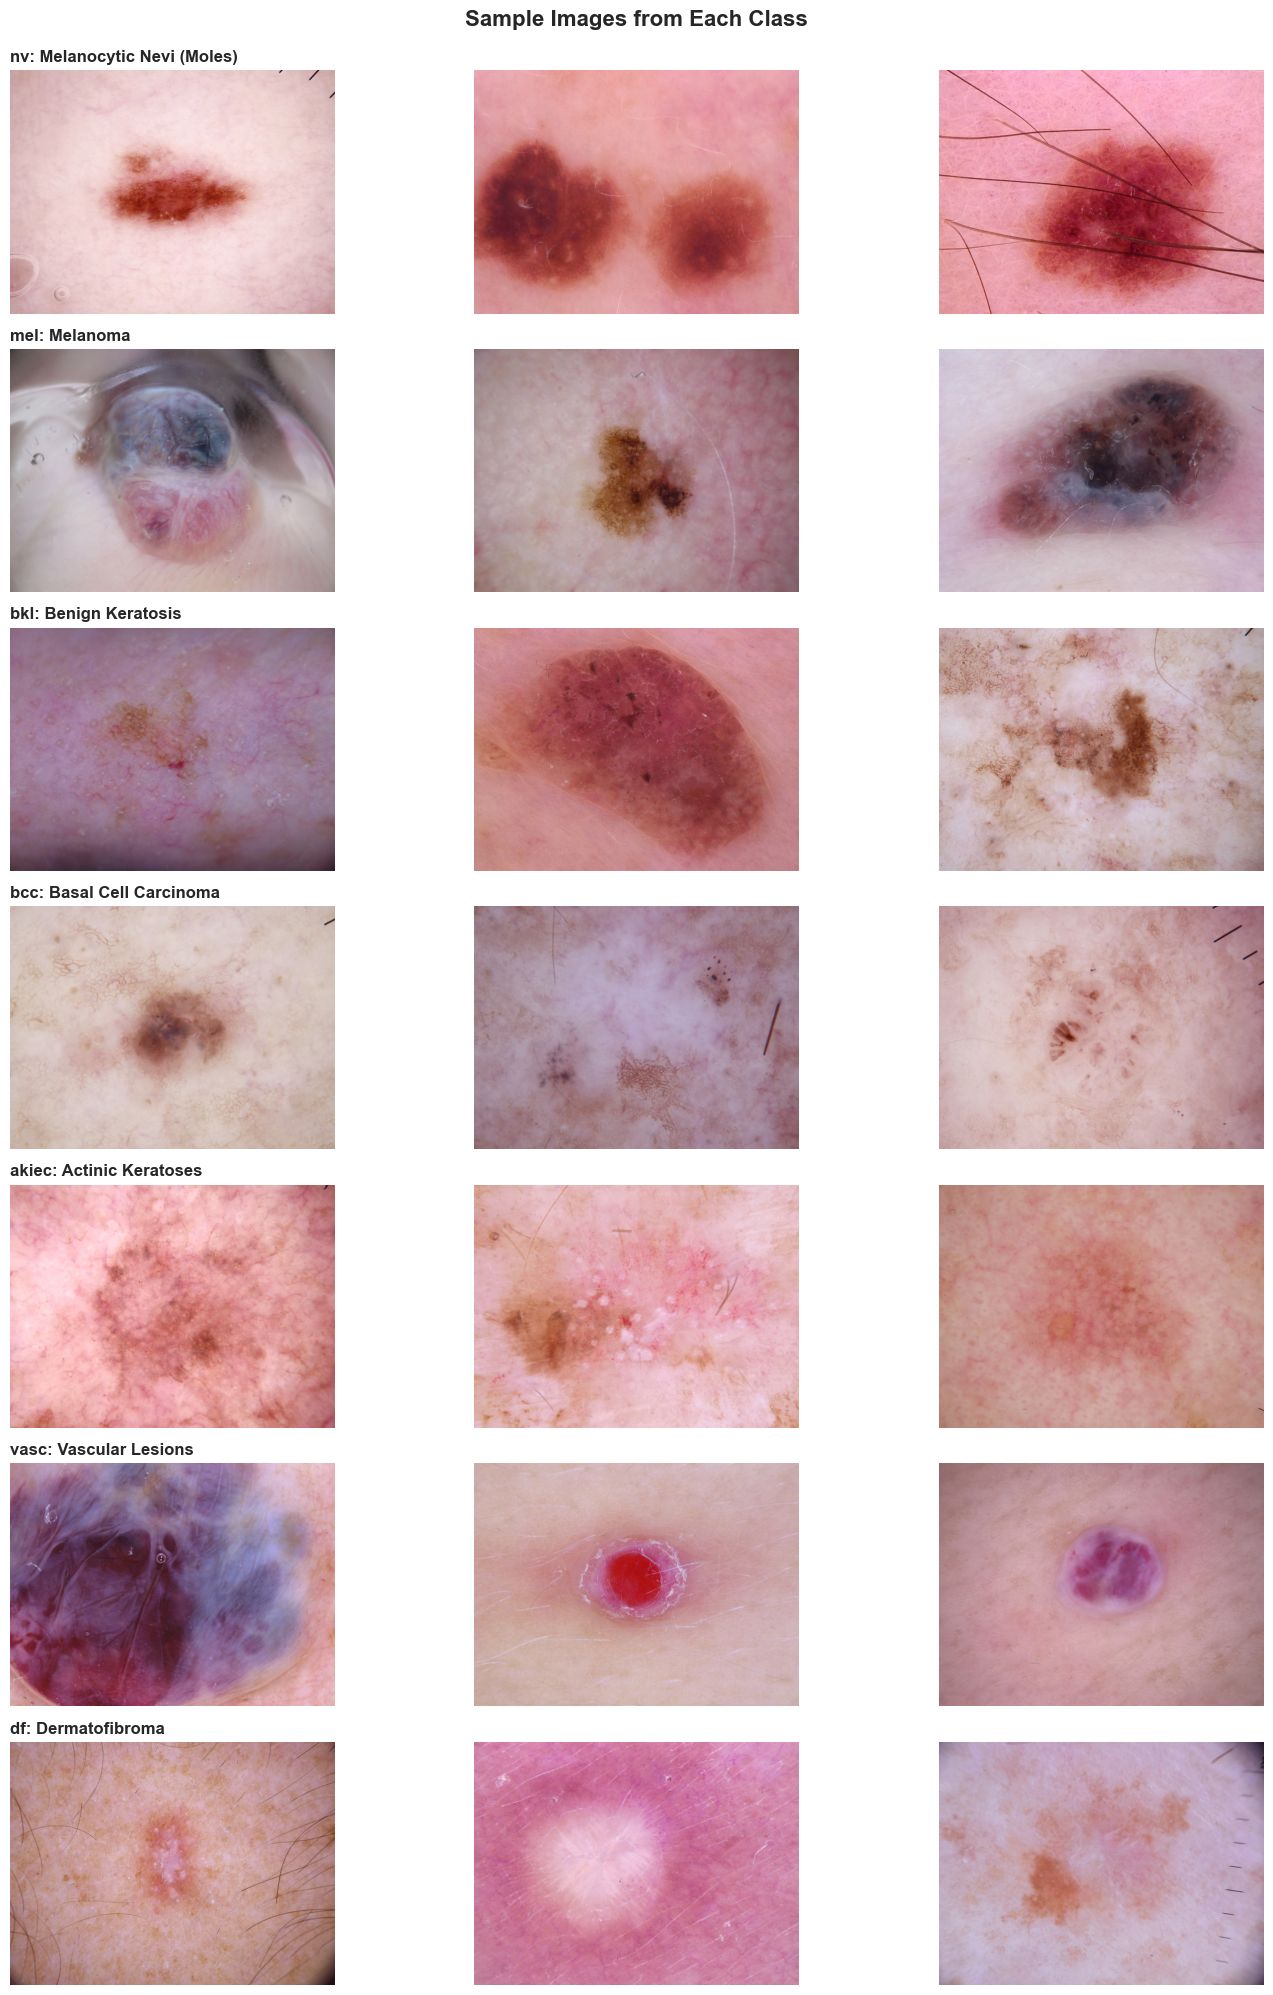

In [26]:
def load_image(image_id):
    """Load image from either part_1 or part_2 folder."""
    img_name = f"{image_id}.jpg"
    
    # Check both image folders
    for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        img_path = PROCESSED_DIR / folder / img_name
        if img_path.exists():
            return Image.open(img_path)
    
    return None

# Sample random images from each class
samples_per_class = 3
fig, axes = plt.subplots(len(CLASS_NAMES), samples_per_class, figsize=(15, 20))

for i, (cls_code, cls_name) in enumerate(CLASS_NAMES.items()):
    # Get random samples from this class
    cls_samples = df[df['dx'] == cls_code].sample(n=samples_per_class, random_state=42)
    
    for j, (_, row) in enumerate(cls_samples.iterrows()):
        ax = axes[i, j]
        
        # Load and display image
        img = load_image(row['image_id'])
        if img is not None:
            ax.imshow(img)
            
        ax.axis('off')
        
        # Add title to first column
        if j == 0:
            ax.set_title(f"{cls_code}: {cls_name}", fontsize=12, fontweight='bold', loc='left')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

 Analyzing image properties (sampling 100 images)...

 Image Dimensions:
   Width:  600 ± 0 px (range: 600-600)
   Height: 450 ± 0 px (range: 450-450)
   Aspect Ratio: 1.33 ± 0.00


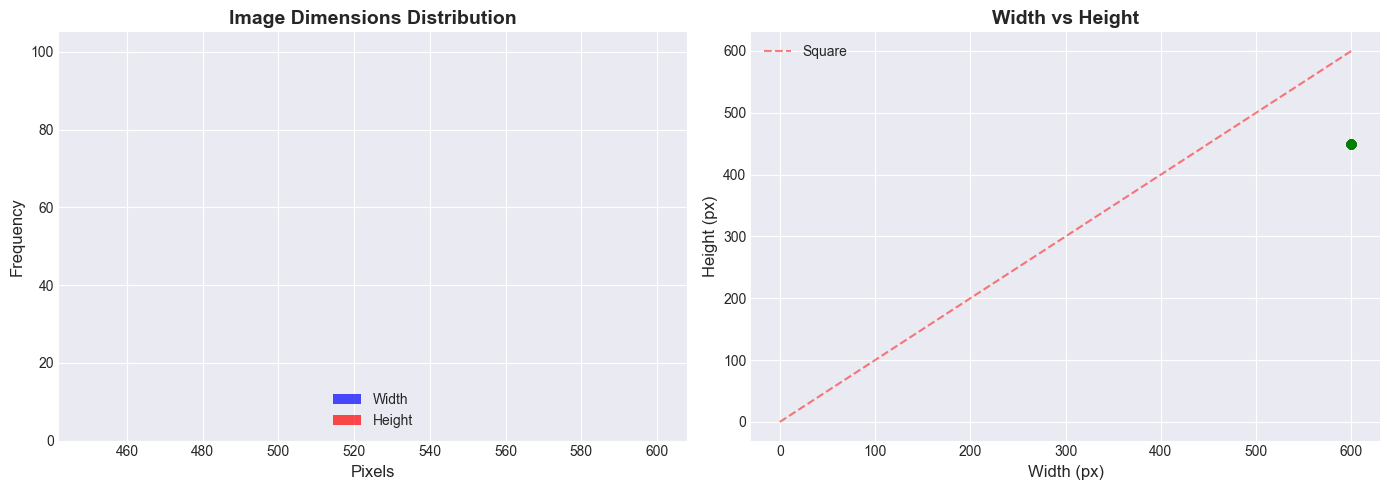

In [27]:
# Analyze image dimensions
print(" Analyzing image properties (sampling 100 images)...\n")

widths = []
heights = []
aspects = []

# Sample 100 random images
sample_ids = df.sample(n=100, random_state=42)['image_id']

for img_id in sample_ids:
    img = load_image(img_id)
    if img is not None:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspects.append(w / h)

print(f" Image Dimensions:")
print(f"   Width:  {np.mean(widths):.0f} ± {np.std(widths):.0f} px (range: {np.min(widths)}-{np.max(widths)})")
print(f"   Height: {np.mean(heights):.0f} ± {np.std(heights):.0f} px (range: {np.min(heights)}-{np.max(heights)})")
print(f"   Aspect Ratio: {np.mean(aspects):.2f} ± {np.std(aspects):.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=20, alpha=0.7, label='Width', color='blue')
axes[0].hist(heights, bins=20, alpha=0.7, label='Height', color='red')
axes[0].set_xlabel('Pixels', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Image Dimensions Distribution', fontsize=14, fontweight='bold')
axes[0].legend()

axes[1].scatter(widths, heights, alpha=0.5, color='green')
axes[1].set_xlabel('Width (px)', fontsize=12)
axes[1].set_ylabel('Height (px)', fontsize=12)
axes[1].set_title('Width vs Height', fontsize=14, fontweight='bold')
axes[1].plot([0, max(widths)], [0, max(widths)], 'r--', alpha=0.5, label='Square')
axes[1].legend()

plt.tight_layout()
plt.show()

In [28]:
print("="*60)
print("🎯 KEY FINDINGS - EDA SUMMARY")
print("="*60)
print()
print("1️⃣  DATASET SIZE:")
print(f"   Total images: {len(df):,}")
print(f"   Train/Val/Test: {split_counts['train']}/{split_counts['val']}/{split_counts['test']}")
print()
print("2️⃣  CLASS IMBALANCE:")
print(f"   Most common: {class_counts.idxmax()} ({CLASS_NAMES[class_counts.idxmax()]}) - {class_counts.max()} samples")
print(f"   Least common: {class_counts.idxmin()} ({CLASS_NAMES[class_counts.idxmin()]}) - {class_counts.min()} samples")
print(f"   Imbalance ratio: {class_counts.max() / class_counts.min():.1f}:1")
print()
print("3️⃣  CRITICAL CLASS (Melanoma):")
print(f"   Samples: {class_counts['mel']} ({class_percentages['mel']}%)")
print(f"   ⚠️  This is our high-sensitivity target!")
print()
print("4️⃣  IMAGE PROPERTIES:")
print(f"   Typical size: ~600x450 px")
print(f"   Will resize to: 224x224 (EfficientNet input)")
print()
print("5️⃣  DATA CHALLENGES:")
print("   ✓ Severe class imbalance → Use Focal Loss")
print("   ✓ Hair occlusions → Augmentations needed")
print("   ✓ Variable lighting → Brightness augmentation")
print("   ✓ Ink markers/rulers → Model must learn to ignore")
print()
print("="*60)

🎯 KEY FINDINGS - EDA SUMMARY

1️⃣  DATASET SIZE:
   Total images: 10,015
   Train/Val/Test: 8012/1001/1002

2️⃣  CLASS IMBALANCE:
   Most common: nv (Melanocytic Nevi (Moles)) - 6705 samples
   Least common: df (Dermatofibroma) - 115 samples
   Imbalance ratio: 58.3:1

3️⃣  CRITICAL CLASS (Melanoma):
   Samples: 1113 (11.11333000499251%)
   ⚠️  This is our high-sensitivity target!

4️⃣  IMAGE PROPERTIES:
   Typical size: ~600x450 px
   Will resize to: 224x224 (EfficientNet input)

5️⃣  DATA CHALLENGES:
   ✓ Severe class imbalance → Use Focal Loss
   ✓ Hair occlusions → Augmentations needed
   ✓ Variable lighting → Brightness augmentation
   ✓ Ink markers/rulers → Model must learn to ignore

